# ArtInsight — inspección del dataset en formato VIA

Notebook para inspeccionar los JSON del dataset ArtInsight cuando las anotaciones vienen en formato **VIA (VGG Image Annotator)**.

Incluye carga del JSON, inspección de estructura, apertura de imagen, visualización de polígonos, generación de máscara binaria, conteo de clases, detección de regiones inválidas y cálculo de áreas.

## 0. Imports y configuración

In [2]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image, ImageDraw

# Ajusta estas rutas a tu entorno
ROOT = Path('/content/drive/MyDrive/')
JSON_PATH = ROOT / 'Dataset' / 'lpl' / 'train' / 'lpl_train.json'

print('ROOT =', ROOT)
print('JSON_PATH =', JSON_PATH)
print('Existe ROOT:', ROOT.exists())
print('Existe JSON_PATH:', JSON_PATH.exists())

ROOT = /content/drive/MyDrive
JSON_PATH = /content/drive/MyDrive/Dataset/lpl/train/lpl_train.json
Existe ROOT: True
Existe JSON_PATH: True


## 1. Cargar JSON VIA

In [3]:
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(type(data))
print('Número de entradas:', len(data))

first_key = next(iter(data))
print('Primera key:', first_key)
print('Claves de la entrada:', data[first_key].keys())

<class 'dict'>
Número de entradas: 6
Primera key: Pintura_0.3.jpg7891517
Claves de la entrada: dict_keys(['fileref', 'size', 'filename', 'base64_img_data', 'file_attributes', 'regions'])


## 2. Inspección de una entrada

In [4]:
sample = data[first_key]

print('filename:', sample['filename'])
print('n_regions:', len(sample['regions']))

region0 = sample['regions']['0'] if '0' in sample['regions'] else next(iter(sample['regions'].values()))
print('region keys:', region0.keys())
print('shape_attributes:', region0['shape_attributes'].keys())
print('region_attributes:', region0['region_attributes'])

filename: Pintura_0.3.jpg
n_regions: 57
region keys: dict_keys(['shape_attributes', 'region_attributes'])
shape_attributes: dict_keys(['name', 'all_points_x', 'all_points_y'])
region_attributes: {'damage': '1'}


## 3. Listar varias entradas del JSON

In [5]:
for i, (k, v) in enumerate(data.items()):
    print(f'Entrada {i}')
    print('  key:', k)
    print('  filename:', v['filename'])
    print('  n_regions:', len(v['regions']))
    print()
    if i == 2:
        break

Entrada 0
  key: Pintura_0.3.jpg7891517
  filename: Pintura_0.3.jpg
  n_regions: 57

Entrada 1
  key: Pintura_0.6.jpg10235854
  filename: Pintura_0.6.jpg
  n_regions: 1

Entrada 2
  key: Pintura_0.12.jpg13298748
  filename: Pintura_0.12.jpg
  n_regions: 40



## 4. Abrir una imagen real

Ruta imagen: /content/drive/MyDrive/Dataset/lpl/train/Pintura_0.3.jpg
Existe: True
Tamaño: (3671, 2815)


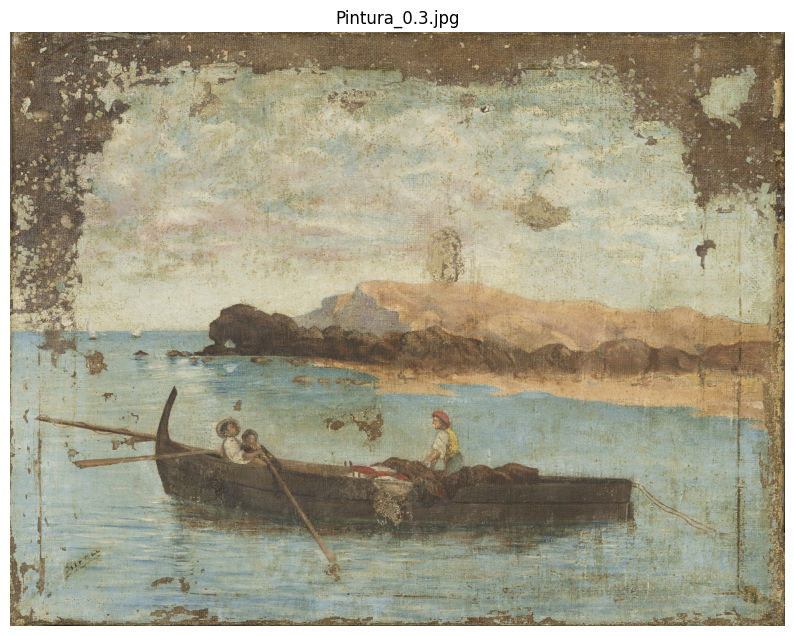

In [6]:
base_dir = JSON_PATH.parent
img_path = base_dir / sample['filename']

print('Ruta imagen:', img_path)
print('Existe:', img_path.exists())

img = Image.open(img_path).convert('RGB')
img_np = np.array(img)

print('Tamaño:', img.size)

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.title(sample['filename'])
plt.axis('off')
plt.show()

## 5. Dibujar polígonos encima de la imagen

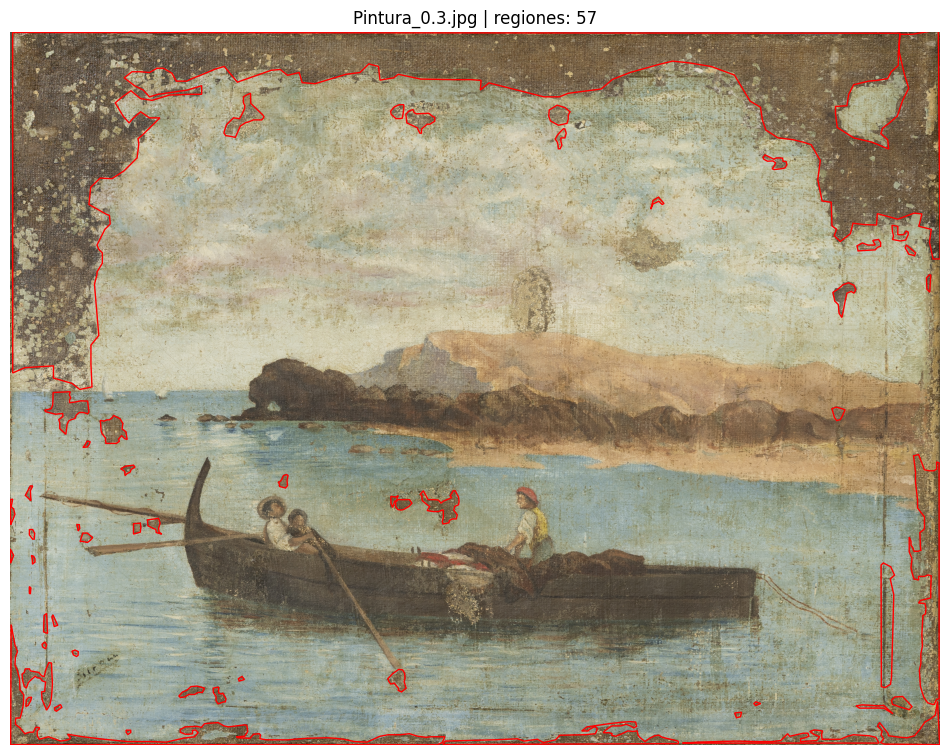

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img_np)

for region_id, region in sample['regions'].items():
    shape = region['shape_attributes']
    xs = shape['all_points_x']
    ys = shape['all_points_y']

    if len(xs) != len(ys) or len(xs) < 3:
        continue

    coords = np.column_stack([xs, ys])
    patch = Polygon(coords, fill=False, edgecolor='red', linewidth=1)
    ax.add_patch(patch)

ax.set_title(f"{sample['filename']} | regiones: {len(sample['regions'])}")
ax.axis('off')
plt.show()

## 6. Generar máscara binaria

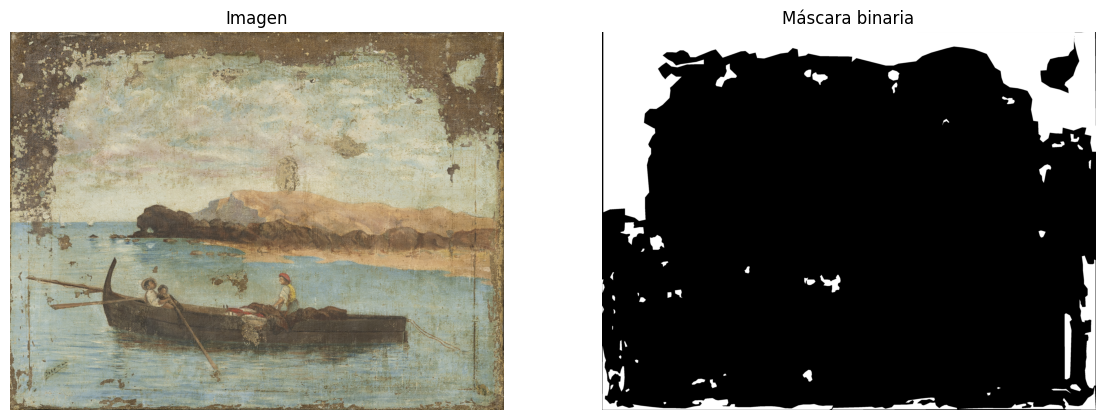

Valores únicos: [0 1]
Pixeles positivos: 1702087


In [8]:
width, height = img.size
mask = Image.new('L', (width, height), 0)
draw = ImageDraw.Draw(mask)

for region_id, region in sample['regions'].items():
    shape = region['shape_attributes']
    xs = shape['all_points_x']
    ys = shape['all_points_y']

    if len(xs) != len(ys) or len(xs) < 3:
        continue

    polygon = list(zip(xs, ys))
    draw.polygon(polygon, outline=1, fill=1)

mask_np = np.array(mask)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title('Imagen')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_np, cmap='gray')
plt.title('Máscara binaria')
plt.axis('off')
plt.show()

print('Valores únicos:', np.unique(mask_np))
print('Pixeles positivos:', int(mask_np.sum()))

## 7. Contar valores de clase (`damage`)

In [9]:
damage_counter = Counter()

for entry in data.values():
    for region in entry['regions'].values():
        damage = region.get('region_attributes', {}).get('damage', 'missing')
        damage_counter[damage] += 1

print(damage_counter)

Counter({'1': 173})


## 8. Detectar regiones inválidas

In [10]:
invalid_regions = []

for image_key, entry in data.items():
    for region_id, region in entry['regions'].items():
        shape = region.get('shape_attributes', {})
        xs = shape.get('all_points_x', [])
        ys = shape.get('all_points_y', [])

        if len(xs) != len(ys) or len(xs) < 3:
            invalid_regions.append((entry['filename'], region_id, 'bad_polygon_length'))

print('Regiones inválidas:', len(invalid_regions))
print(invalid_regions[:10])

Regiones inválidas: 4
[('Pintura_0.3.jpg', '2', 'bad_polygon_length'), ('Pintura_0.3.jpg', '49', 'bad_polygon_length'), ('Pintura_0.3.jpg', '51', 'bad_polygon_length'), ('Pintura_0.19.jpg', '23', 'bad_polygon_length')]


## 9. Calcular áreas de polígonos

In [11]:
def polygon_area(xs, ys):
    xs = np.array(xs)
    ys = np.array(ys)
    return 0.5 * abs(np.dot(xs, np.roll(ys, 1)) - np.dot(ys, np.roll(xs, 1)))

areas = []

for entry in data.values():
    for region in entry['regions'].values():
        shape = region['shape_attributes']
        xs = shape['all_points_x']
        ys = shape['all_points_y']

        if len(xs) == len(ys) and len(xs) >= 3:
            area = polygon_area(xs, ys)
            areas.append((entry['filename'], area))

print('Top 10 regiones más grandes:')
for x in sorted(areas, key=lambda x: x[1], reverse=True)[:10]:
    print(x)

print('\nTop 10 regiones más pequeñas:')
for x in sorted(areas, key=lambda x: x[1])[:10]:
    print(x)

Top 10 regiones más grandes:
('Pintura_0.3.jpg', np.float64(1378276.5))
('Pintura_0.18.jpg', np.float64(161045.0))
('Pintura_0.18.jpg', np.float64(101684.5))
('Pintura_0.12.jpg', np.float64(91753.0))
('Pintura_0.12.jpg', np.float64(91661.5))
('Pintura_0.18.jpg', np.float64(73764.0))
('Pintura_0.3.jpg', np.float64(68989.0))
('Pintura_0.12.jpg', np.float64(67470.5))
('Pintura_0.3.jpg', np.float64(67049.5))
('Pintura_0.12.jpg', np.float64(48363.5))

Top 10 regiones más pequeñas:
('Pintura_0.3.jpg', np.float64(128.0))
('Pintura_0.3.jpg', np.float64(180.0))
('Pintura_0.3.jpg', np.float64(210.0))
('Pintura_0.3.jpg', np.float64(232.5))
('Pintura_0.3.jpg', np.float64(234.0))
('Pintura_0.19.jpg', np.float64(262.0))
('Pintura_0.3.jpg', np.float64(274.0))
('Pintura_0.3.jpg', np.float64(292.0))
('Pintura_0.19.jpg', np.float64(332.0))
('Pintura_0.19.jpg', np.float64(336.0))


## 10. Resumen por imagen

In [12]:
summary = []

for entry in data.values():
    summary.append((entry['filename'], len(entry['regions'])))

for item in sorted(summary, key=lambda x: x[1], reverse=True):
    print(item)

('Pintura_0.3.jpg', 57)
('Pintura_0.12.jpg', 40)
('Pintura_0.18.jpg', 34)
('Pintura_0.19.jpg', 28)
('Pintura_0.15.jpg', 13)
('Pintura_0.6.jpg', 1)


## 11. Checklist final

- ¿El JSON está en formato VIA?
- ¿Las rutas de imagen resuelven bien?
- ¿Los polígonos se dibujan correctamente?
- ¿La máscara binaria sale bien?
- ¿Todas las regiones tienen `damage`?
- ¿Hay regiones inválidas?
- ¿Hay regiones desproporcionadamente grandes o pequeñas?

No avances al modelo hasta que esto esté controlado.